In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'EG'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'EG',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.07,
 'fee': 3,
 'fee_way': 'number',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '乙二醇'}

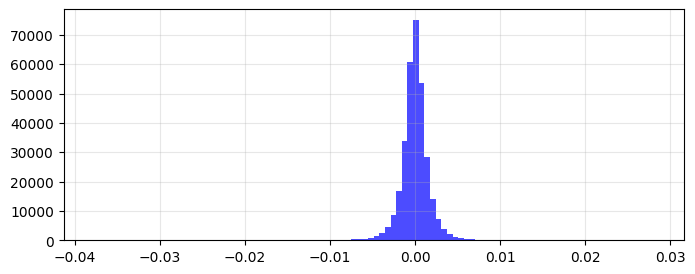


Fold 1/5
Fold 1 验证集日期范围: 2021-02-02 09:11:00 至 2021-12-21 14:46:00
Fold 1 训练集样本数: 254775, 验证集样本数: 63694
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992114
[200]	valid_0's l2: 0.992273
[300]	valid_0's l2: 0.992312
[400]	valid_0's l2: 0.992415
[500]	valid_0's l2: 0.992521
[600]	valid_0's l2: 0.992684
Early stopping, best iteration is:
[102]	valid_0's l2: 0.992104


<Figure size 1000x600 with 0 Axes>

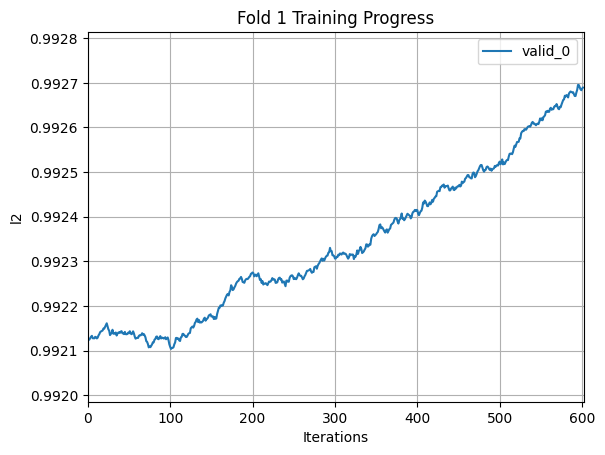

valid ic: 0.004314970359417373
模型最佳迭代次数 = 102

Fold 2/5
Fold 2 验证集日期范围: 2021-12-21 14:47:00 至 2022-11-10 09:59:00
Fold 2 训练集样本数: 254775, 验证集样本数: 63694
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.99232
[200]	valid_0's l2: 0.992284
[300]	valid_0's l2: 0.992291
[400]	valid_0's l2: 0.992304
[500]	valid_0's l2: 0.992301
[600]	valid_0's l2: 0.992336
Early stopping, best iteration is:
[189]	valid_0's l2: 0.992277


<Figure size 1000x600 with 0 Axes>

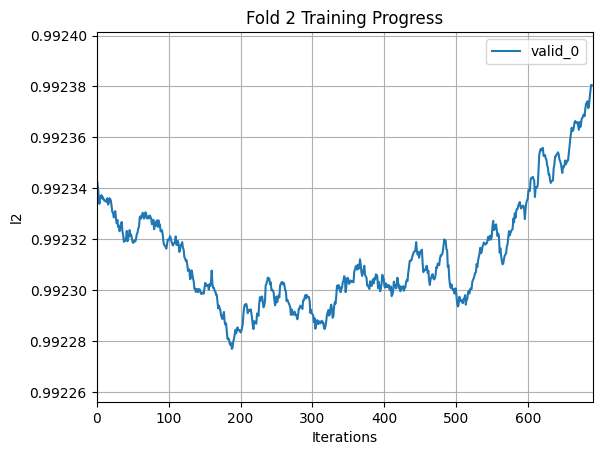

valid ic: 0.00975121191066325
模型最佳迭代次数 = 189

Fold 3/5
Fold 3 验证集日期范围: 2022-11-10 10:00:00 至 2023-09-21 21:59:00
Fold 3 训练集样本数: 254775, 验证集样本数: 63694
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992275
[200]	valid_0's l2: 0.992267
[300]	valid_0's l2: 0.992256
[400]	valid_0's l2: 0.99224
[500]	valid_0's l2: 0.992226
[600]	valid_0's l2: 0.992226
[700]	valid_0's l2: 0.992224
[800]	valid_0's l2: 0.992232
[900]	valid_0's l2: 0.992233
[1000]	valid_0's l2: 0.992229
Early stopping, best iteration is:
[564]	valid_0's l2: 0.992215


<Figure size 1000x600 with 0 Axes>

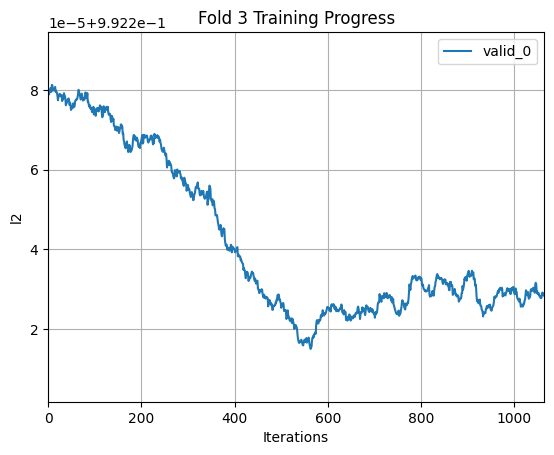

valid ic: 0.009086358653224453
模型最佳迭代次数 = 564

Fold 4/5
Fold 4 验证集日期范围: 2023-09-21 22:00:00 至 2024-08-12 09:12:00
Fold 4 训练集样本数: 254775, 验证集样本数: 63694
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992342
[200]	valid_0's l2: 0.99233
[300]	valid_0's l2: 0.992323
[400]	valid_0's l2: 0.992313
[500]	valid_0's l2: 0.992309
[600]	valid_0's l2: 0.992286
[700]	valid_0's l2: 0.992295
[800]	valid_0's l2: 0.992306
[900]	valid_0's l2: 0.992305
[1000]	valid_0's l2: 0.99231
[1100]	valid_0's l2: 0.992312
Early stopping, best iteration is:
[606]	valid_0's l2: 0.992285


<Figure size 1000x600 with 0 Axes>

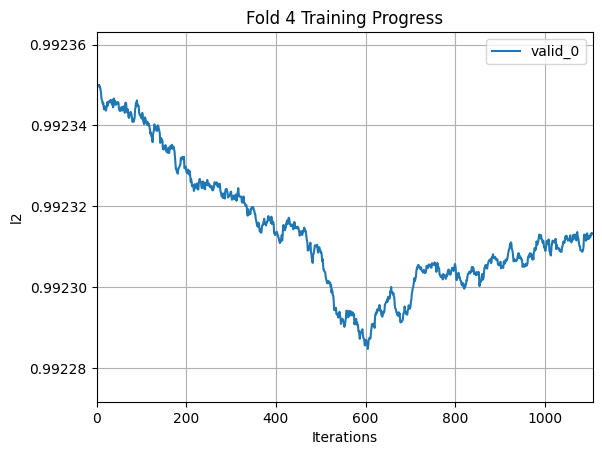

valid ic: 0.008688413467685544
模型最佳迭代次数 = 606

Fold 5/5
Fold 5 验证集日期范围: 2024-08-12 09:13:00 至 2025-07-01 22:49:00
Fold 5 训练集样本数: 254776, 验证集样本数: 63693
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992483
[200]	valid_0's l2: 0.992497
[300]	valid_0's l2: 0.992508
[400]	valid_0's l2: 0.992516
[500]	valid_0's l2: 0.992509
Early stopping, best iteration is:
[8]	valid_0's l2: 0.992465


<Figure size 1000x600 with 0 Axes>

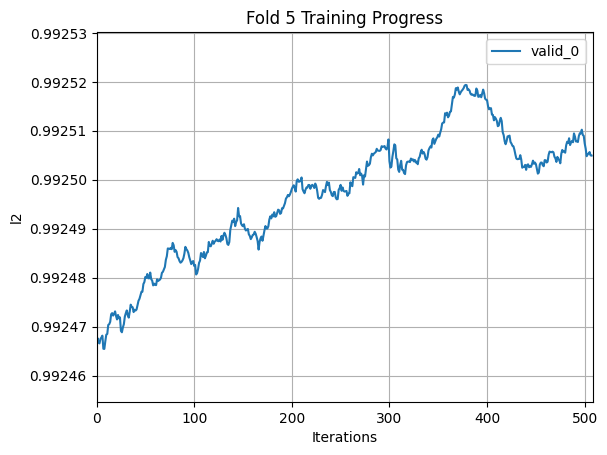

valid ic: 0.0055049451206982325
模型最佳迭代次数 = 8
特征重要性已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/importance/2025-07-01_EG_5_feature_importance_reg.csv
特征相关系数表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/correlation/2025-07-01_EG_5_feature_corr.csv


/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/group/2025-07-01_EG_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_RU|_BR|_NR|_L|_TA|_PF|_V|_EG|_MA|_PP|_EB|_UR|_SA|_SH|_PX|_PR|RU_|BR_|NR_|L_|TA_|PF_|V_|EG_|MA_|PP_|EB_|UR_|SA_|SH_|PX_|PR_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1927， 筛选之后因子数量：1851

特征重要性过滤： 300 200 	待筛因子个数 1851
无向因子有效个数： 895 有向因子有效个数： 785
  选择有向特征 224 个，重要性范围: 284.00 - 7.00
  选择无向特征 135 个，重要性范围: 440.00 - 13.00

单因子sharpe过滤： 0.5 sp范围-5.3027 ~ 5.9255   待筛因子个数 359

特征相关性性过滤： 300     待筛因子个数 270
  选择特征 204 个, 特征最大相关性0.8976892136323928

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_jump', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_jump', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

排除指定因子后，剩余特征 202 个


(123, 0, 55, 24)

正在从 /mnt/Data/writable/liaoyuyang/factor/EG/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (318166, 1931)
训练集时间范围: 2021-02-02 09:11:00 至 2025-06-30 22:49:00
[200]	valid_0's rmse: 0.996501
[400]	valid_0's rmse: 0.997066


<Figure size 1000x600 with 0 Axes>

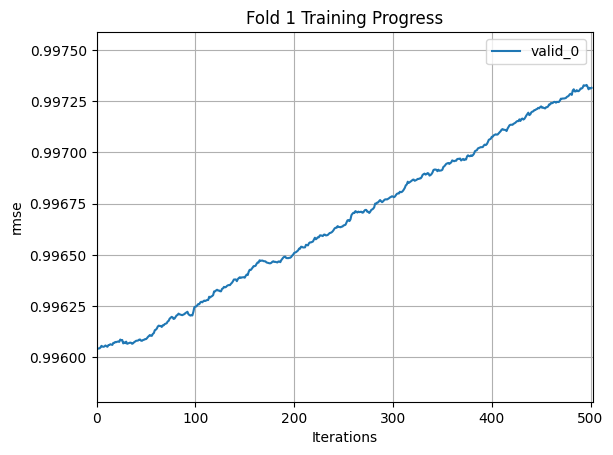

{'train_rmse': np.float64(0.9999703107158916), 'val_rmse': np.float64(0.9999929129667418), 'best_iteration': 2}
test_corr: -0.0123
[200]	valid_0's rmse: 0.996113
[400]	valid_0's rmse: 0.996301
[600]	valid_0's rmse: 0.996406


<Figure size 1000x600 with 0 Axes>

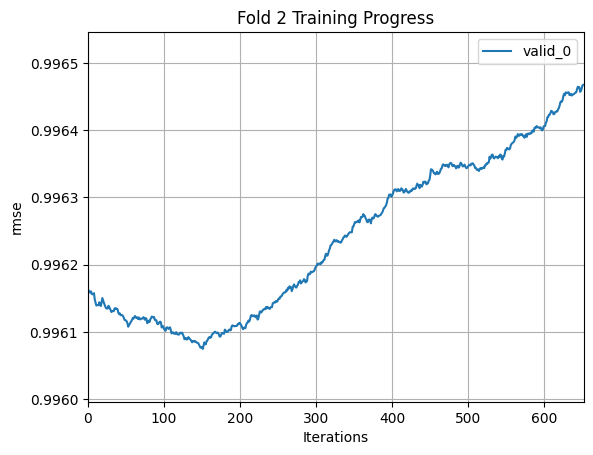

{'train_rmse': np.float64(0.9971806361094837), 'val_rmse': np.float64(0.9999146927096976), 'best_iteration': 152}
test_corr: -0.0092
[200]	valid_0's rmse: 0.996124
[400]	valid_0's rmse: 0.996115


<Figure size 1000x600 with 0 Axes>

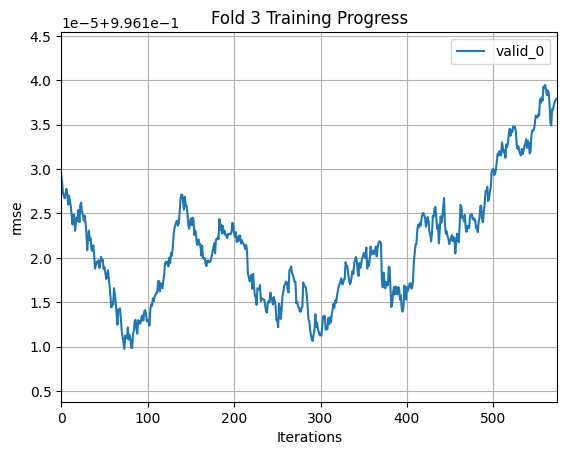

{'train_rmse': np.float64(0.9985783271718331), 'val_rmse': np.float64(0.9999829616614961), 'best_iteration': 74}
test_corr: -0.0163
[200]	valid_0's rmse: 0.996159
[400]	valid_0's rmse: 0.996166


<Figure size 1000x600 with 0 Axes>

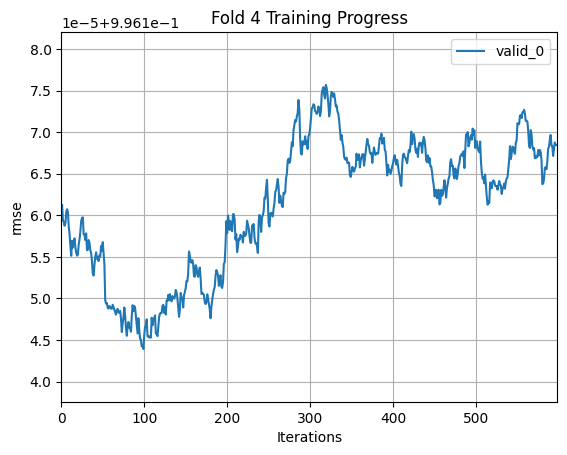

{'train_rmse': np.float64(0.9982618159383544), 'val_rmse': np.float64(0.9999860181258082), 'best_iteration': 98}
test_corr: -0.0124
[200]	valid_0's rmse: 0.996259
[400]	valid_0's rmse: 0.996261


<Figure size 1000x600 with 0 Axes>

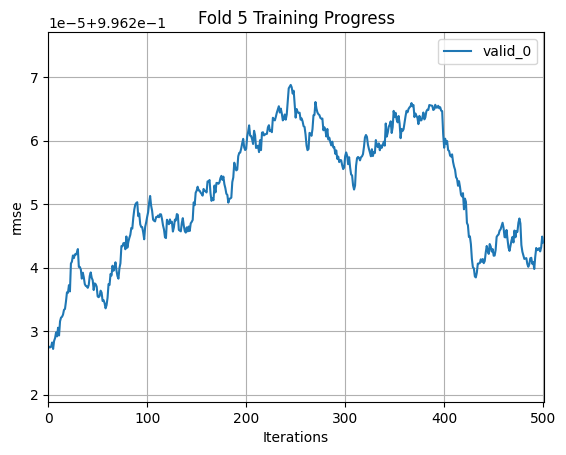

{'train_rmse': np.float64(0.9999816797322749), 'val_rmse': np.float64(1.0000063833112656), 'best_iteration': 1}
test_corr: -0.0062


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/EG_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
merged_data = bt.backtest(th1=0.8, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/39208 [00:00<?, ?it/s]

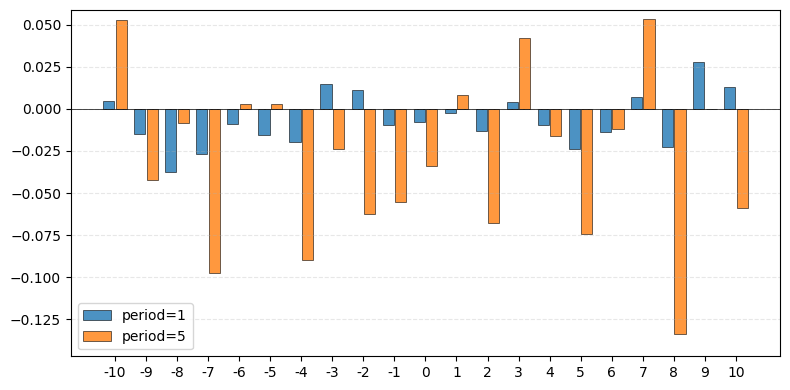

In [10]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [11]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,2228
空头(-1) 数量,12279
空仓(0) 数量,24703
多头占比,5.68%
空头占比,31.32%
空仓占比,63.00%
交易日数量,115
总收益(非年化%),1.31
总交易次数（开平算一次）,1728
每笔收益(%%),0.08


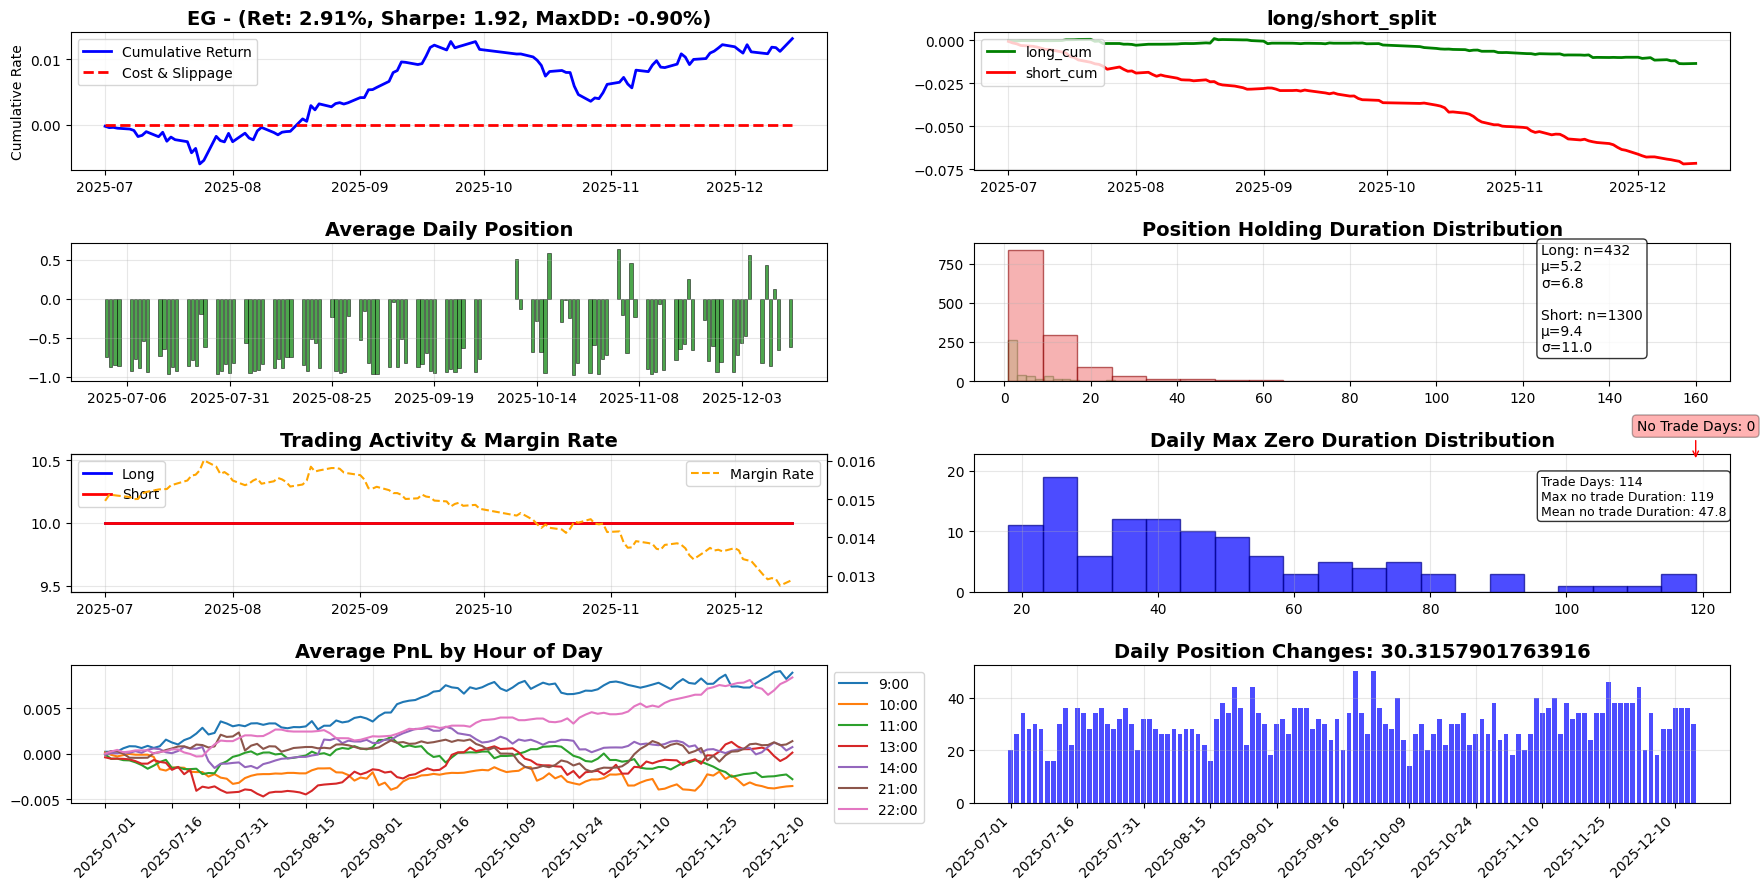

In [12]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [13]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: EG
📅 总交易日数: 114
📊 总数据点: 41382
🎯 使用导航按钮或输入页码进行浏览


In [14]:
bv.plot_yearly_eval(merged_data)